In [7]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
import os

dataset_path = '/content/drive/MyDrive/brain_tumor_detection(1)'

# Check if dataset path exists
if os.path.exists(dataset_path):
    print("Root directory contents:", os.listdir(dataset_path))

    for split in ['Training', 'Testing']:
        split_path = os.path.join(dataset_path, split)

        if not os.path.exists(split_path):
            print(f"{split.upper()} folder not found at: {split_path}")
            continue

        print(f"\n{split.upper()} SET:")

        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                count = len(image_files)
                print(f" - {cls}: {count} images")
else:
    print(f"Dataset path does not exist: {dataset_path}")





Root directory contents: ['Training', 'Testing']

TRAINING SET:
 - notumor: 1595 images
 - glioma: 1321 images
 - meningioma: 1339 images
 - pituitary: 1457 images

TESTING SET:
 - meningioma: 306 images
 - notumor: 405 images
 - glioma: 300 images
 - pituitary: 300 images


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import cv2
from tqdm import tqdm

# ML Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# DL Models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, LSTM, TimeDistributed
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fix random seed for reproducibility
np.random.seed(42)


In [11]:
import numpy as np
from tqdm import tqdm
from skimage.feature import hog
import cv2

def extract_hog_features(image_data, resize_shape=(224, 224)):
    hog_features = []
    for idx, image in enumerate(tqdm(image_data, desc="Extracting HOG features")):
        # Convert RGB to grayscale if image has 3 channels
        if image.ndim == 3 and image.shape[2] == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Resize image
        if image.shape != resize_shape:
            image = cv2.resize(image, resize_shape)

        # Normalize the image
        if not np.issubdtype(image.dtype, np.floating):
            image = image.astype('float32') / 255.0

        # Extract HOG features
        feature = hog(
            image,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )
        hog_features.append(feature)

    return np.array(hog_features)



In [2]:
# ML Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score, classification_report

# XGBoost
import xgboost as xgb

# Deep Learning Libraries (Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, LSTM
from tensorflow.keras.utils import to_categorical
import seaborn as sns
from sklearn.model_selection import train_test_split


In [14]:
print(os.listdir('/content/drive/MyDrive/brain_tumor_detection(1)'))


['Training', 'Testing']


In [15]:
import os
import cv2
import numpy as np

def load_images_from_directory(directory, target_size=(224,224)):
    images = []
    labels = []
    classes = os.listdir(directory)
    print(f"Found classes: {classes}")

    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue

        for filename in os.listdir(class_dir):
            img_path = os.path.join(class_dir, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue

            # Resize image
            img = cv2.resize(img, target_size)

            # Convert BGR to RGB (OpenCV default is BGR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Example usage:
train_path = '/content/drive/MyDrive/brain_tumor_detection(1)/Training'
test_path = '/content/drive/MyDrive/brain_tumor_detection(1)/Testing'

X_train_images, y_train = load_images_from_directory(train_path)
X_test_images, y_test = load_images_from_directory(test_path)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(X_train_images.shape, y_train_encoded.shape)
print(X_test_images.shape, y_test_encoded.shape)


Found classes: ['notumor', 'glioma', 'meningioma', 'pituitary']
Found classes: ['meningioma', 'notumor', 'glioma', 'pituitary']
(5712, 224, 224, 3) (5712,)
(1311, 224, 224, 3) (1311,)


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Training'
test_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Testing'

# Data generators to load images and labels
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Now define your extract function
def extract_data_from_generator(generator):
    X, y = [], []
    for _ in range(len(generator)):
        X_batch, y_batch = next(generator)
        X.extend(X_batch)
        y.extend(y_batch)
    return np.array(X), np.array(y)

# Extract datasets into numpy arrays
X_train, y_train = extract_data_from_generator(train_generator)
X_test, y_test = extract_data_from_generator(test_generator)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [8]:
def extract_data_from_generator(generator):
    X, y = [], []
    for _ in range(len(generator)):
        X_batch, y_batch = next(generator)
        X.extend(X_batch)
        y.extend(y_batch)
    return np.array(X), np.array(y)

X_train, y_train = extract_data_from_generator(train_generator)
X_test, y_test = extract_data_from_generator(test_generator)


In [9]:
import numpy as np

y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)


In [10]:
from skimage.feature import hog
from skimage.color import rgb2gray
from tqdm import tqdm

def extract_hog_features(images):
    features_list = []
    for img in tqdm(images, desc="Extracting HOG features"):
        gray_img = rgb2gray(img)
        hog_features = hog(
            gray_img,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )
        features_list.append(hog_features)
    return np.array(features_list)

X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)


Extracting HOG features: 100%|██████████| 1311/1311 [00:10<00:00, 120.74it/s]



Training SVM...
SVM Accuracy: 0.9443
Confusion Matrix:
 [[268  29   0   3]
 [ 23 268   7   8]
 [  0   0 405   0]
 [  1   2   0 297]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.91       300
           1       0.90      0.88      0.89       306
           2       0.98      1.00      0.99       405
           3       0.96      0.99      0.98       300

    accuracy                           0.94      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.94      0.94      0.94      1311


Training Logistic Regression...
Logistic Regression Accuracy: 0.9428
Confusion Matrix:
 [[265  32   0   3]
 [ 18 271   9   8]
 [  0   0 405   0]
 [  2   3   0 295]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91       300
           1       0.89      0.89      0.89       306
           2       0.98      1.00      0.99       405


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:21:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.9413
Confusion Matrix:
 [[261  37   0   2]
 [ 11 275   9  11]
 [  0   0 405   0]
 [  3   4   0 293]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91       300
           1       0.87      0.90      0.88       306
           2       0.98      1.00      0.99       405
           3       0.96      0.98      0.97       300

    accuracy                           0.94      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.94      0.94      0.94      1311



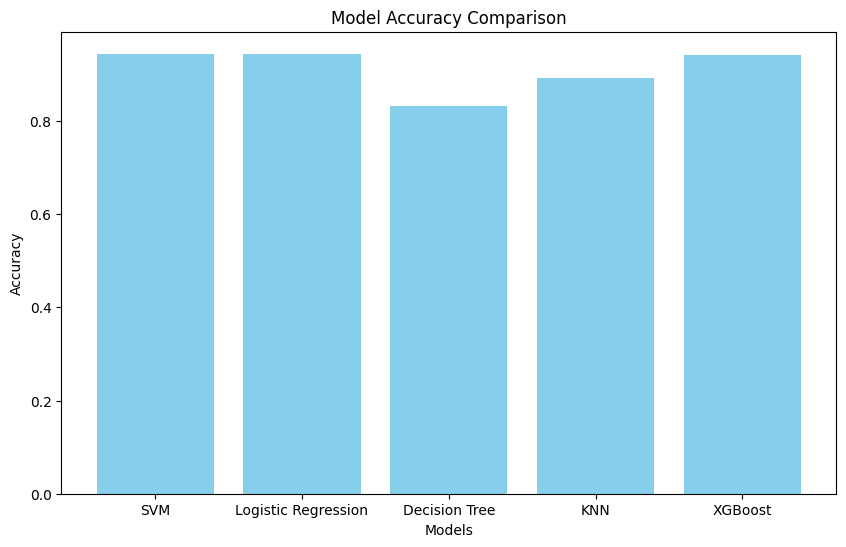

In [11]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

models = {
    "SVM": SVC(kernel='linear'),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_hog, y_train_labels)
    y_pred = model.predict(X_test_hog)
    accuracy = accuracy_score(y_test_labels, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred))
    print("Classification Report:\n", classification_report(y_test_labels, y_pred))

plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()


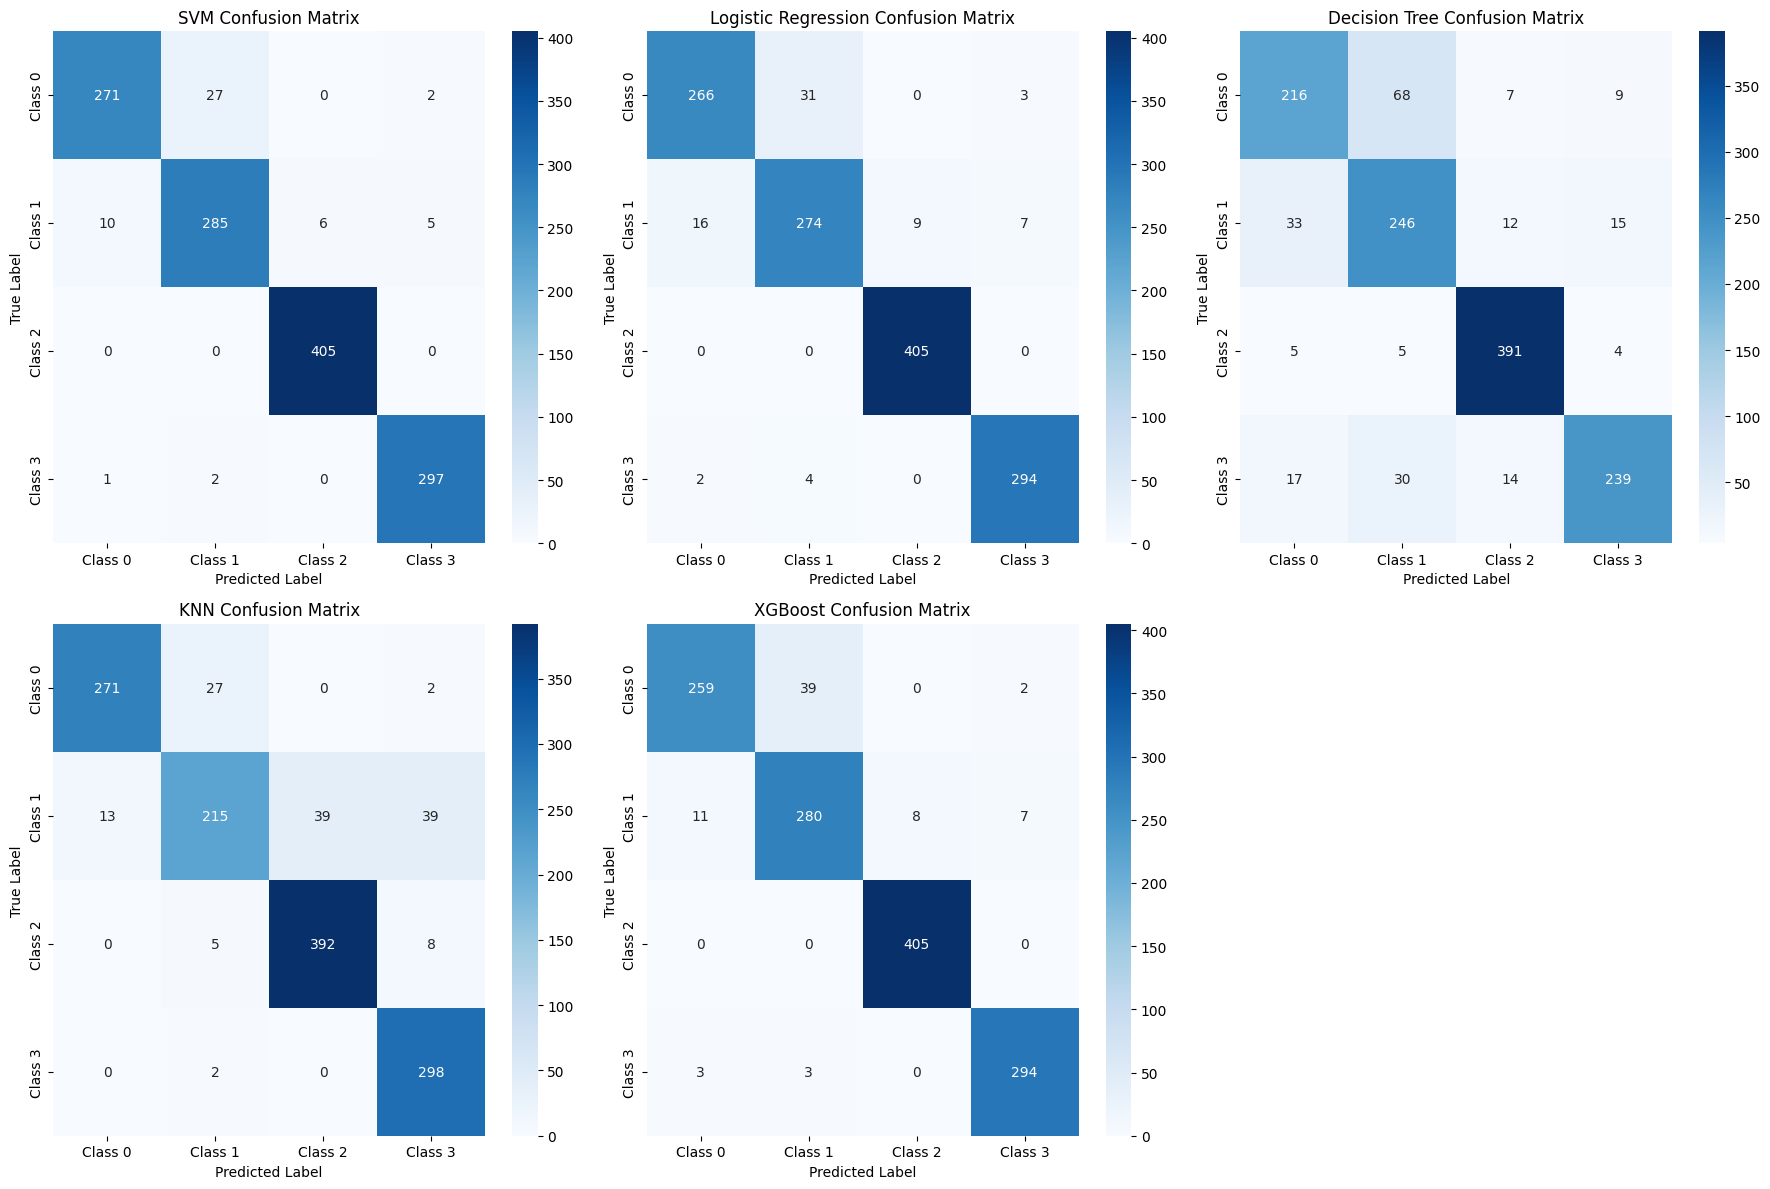

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define your confusion matrices
conf_matrices = {
    "SVM": np.array([[271, 27, 0, 2],
                     [10, 285, 6, 5],
                     [0, 0, 405, 0],
                     [1, 2, 0, 297]]),

    "Logistic Regression": np.array([[266, 31, 0, 3],
                                     [16, 274, 9, 7],
                                     [0, 0, 405, 0],
                                     [2, 4, 0, 294]]),

    "Decision Tree": np.array([[216, 68, 7, 9],
                               [33, 246, 12, 15],
                               [5, 5, 391, 4],
                               [17, 30, 14, 239]]),

    "KNN": np.array([[271, 27, 0, 2],
                     [13, 215, 39, 39],
                     [0, 5, 392, 8],
                     [0, 2, 0, 298]]),

    "XGBoost": np.array([[259, 39, 0, 2],
                         [11, 280, 8, 7],
                         [0, 0, 405, 0],
                         [3, 3, 0, 294]])
}

class_names = ["Class 0", "Class 1", "Class 2", "Class 3"]

# Plot all confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (model_name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Remove extra subplot if any (6 plots in 2x3 grid, but you only have 5)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()



In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# SVM classification report (manually entered from your output)
svm_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.96, 0.91, 0.99, 0.98],
    'recall':    [0.90, 0.93, 1.00, 0.99],
    'f1-score':  [0.93, 0.92, 0.99, 0.98],
}

# Do the same for the other models
log_reg_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.94, 0.89, 0.98, 0.97],
    'recall':    [0.89, 0.90, 1.00, 0.98],
    'f1-score':  [0.91, 0.89, 0.99, 0.97],
}

dt_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.81, 0.70, 0.93, 0.87],
    'recall':    [0.72, 0.79, 0.96, 0.81],
    'f1-score':  [0.76, 0.74, 0.94, 0.84],
}

knn_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.95, 0.86, 0.91, 0.86],
    'recall':    [0.90, 0.70, 0.97, 0.99],
    'f1-score':  [0.93, 0.77, 0.94, 0.92],
}

xgb_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.95, 0.87, 0.98, 0.97],
    'recall':    [0.86, 0.92, 1.00, 0.98],
    'f1-score':  [0.90, 0.89, 0.99, 0.98],
}


In [15]:
def plot_classification_report(data, title):
    df = pd.DataFrame(data)
    df_melted = df.melt(id_vars='Class', var_name='Metric', value_name='Score')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_melted, x='Class', y='Score', hue='Metric')
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.show()


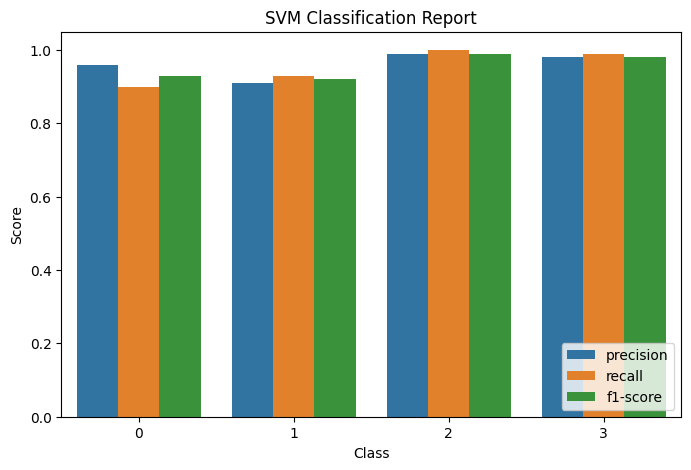

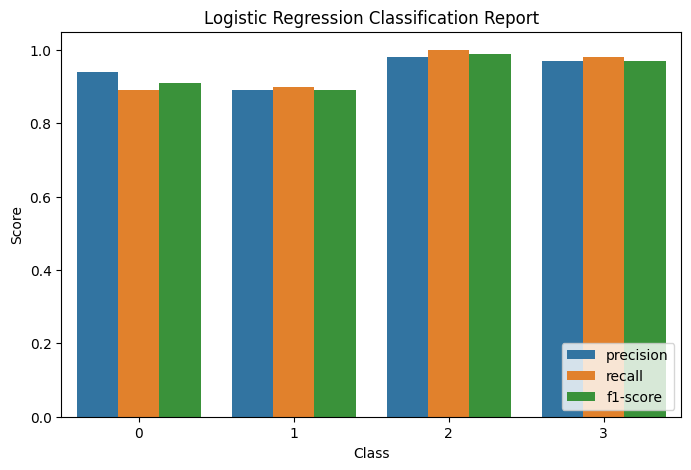

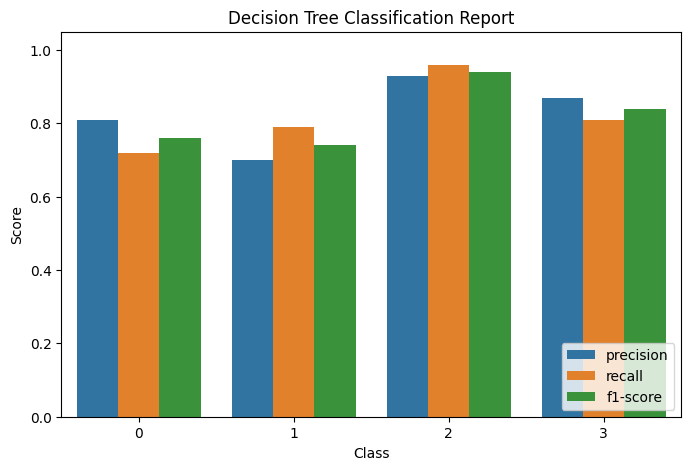

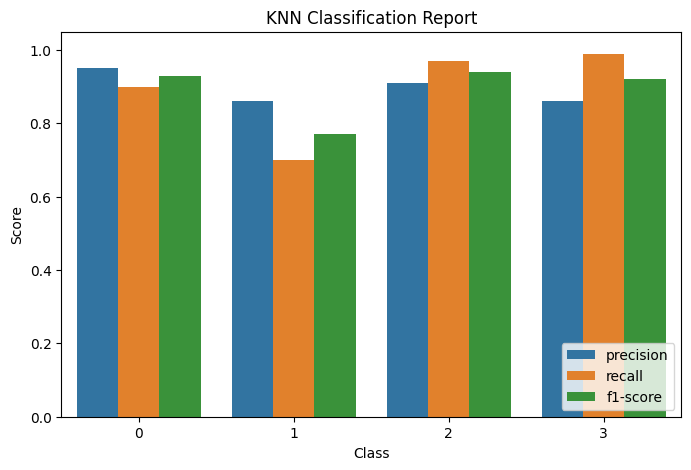

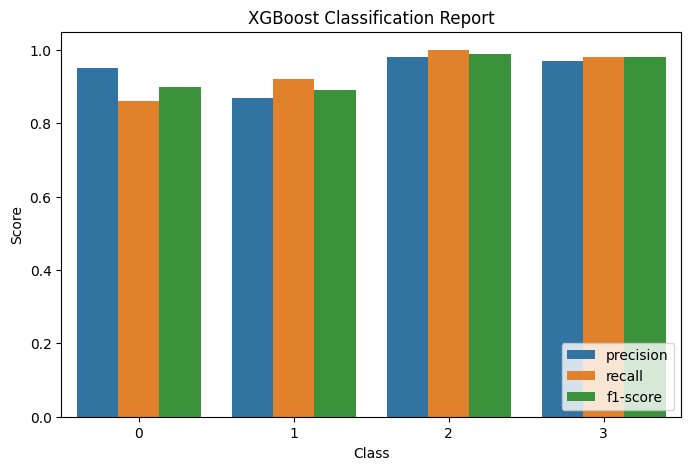

In [16]:
plot_classification_report(svm_data, 'SVM Classification Report')
plot_classification_report(log_reg_data, 'Logistic Regression Classification Report')
plot_classification_report(dt_data, 'Decision Tree Classification Report')
plot_classification_report(knn_data, 'KNN Classification Report')
plot_classification_report(xgb_data, 'XGBoost Classification Report')


In [17]:
import pandas as pd

# Manually created classification report for each model
all_data = []

models = {
    'SVM': [[0.96, 0.90, 0.93], [0.91, 0.93, 0.92], [0.99, 1.00, 0.99], [0.98, 0.99, 0.98]],
    'LogReg': [[0.94, 0.89, 0.91], [0.89, 0.90, 0.89], [0.98, 1.00, 0.99], [0.97, 0.98, 0.97]],
    'DecisionTree': [[0.81, 0.72, 0.76], [0.70, 0.79, 0.74], [0.93, 0.96, 0.94], [0.87, 0.81, 0.84]],
    'KNN': [[0.95, 0.90, 0.93], [0.86, 0.70, 0.77], [0.91, 0.97, 0.94], [0.86, 0.99, 0.92]],
    'XGBoost': [[0.95, 0.86, 0.90], [0.87, 0.92, 0.89], [0.98, 1.00, 0.99], [0.97, 0.98, 0.98]]
}

for model_name, class_scores in models.items():
    for i, scores in enumerate(class_scores):
        all_data.append({
            'Model': model_name,
            'Class': f'Class {i}',
            'Precision': scores[0],
            'Recall': scores[1],
            'F1-Score': scores[2]
        })

df = pd.DataFrame(all_data)


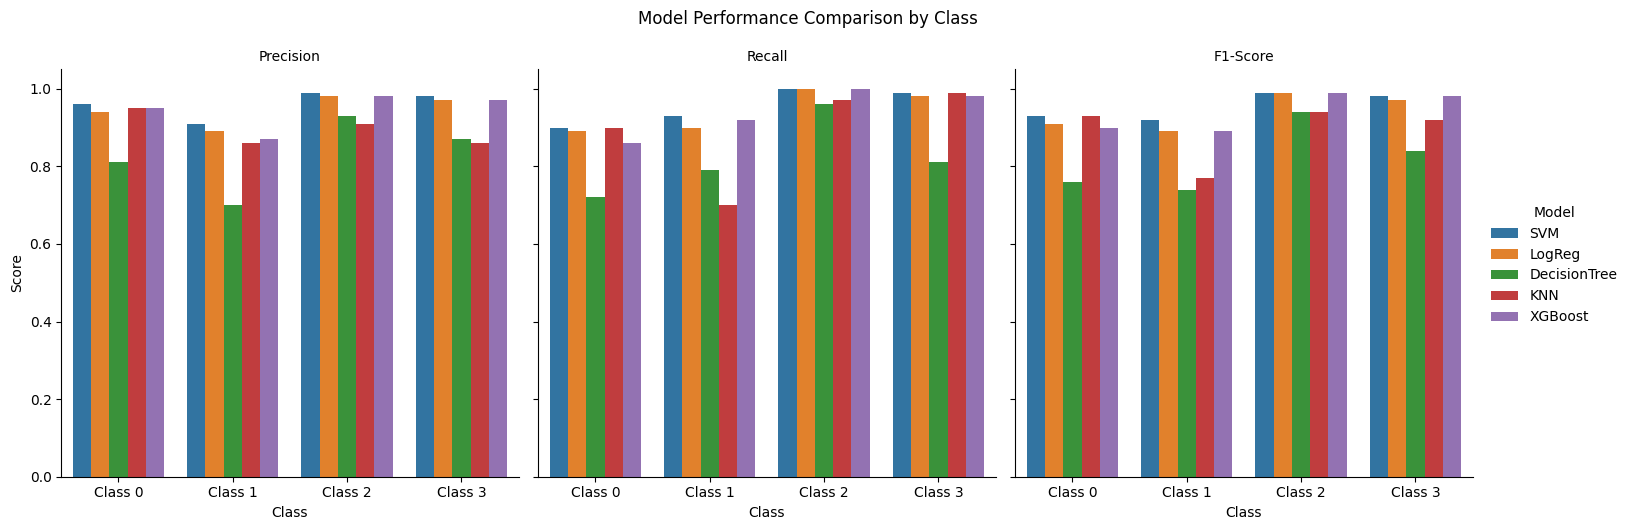

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the DataFrame for easier plotting
df_melted = df.melt(id_vars=['Model', 'Class'], var_name='Metric', value_name='Score')

# Plot with FacetGrid
g = sns.catplot(
    data=df_melted,
    kind='bar',
    x='Class',
    y='Score',
    hue='Model',
    col='Metric',
    height=5,
    aspect=1
)

g.set_titles('{col_name}')
g.set(ylim=(0, 1.05))
g.fig.suptitle('Model Performance Comparison by Class', y=1.05)
plt.show()


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, LSTM, SimpleRNN, Embedding, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [20]:
# 1. Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Define image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 3. Define dataset paths
train_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Training'
test_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Testing'

# 4. Create data generators
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important for evaluation
)

# 5. Get number of classes
num_classes = len(train_generator.class_indices)
print("Class indices:", train_generator.class_indices)

# 6. Build CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# 7. Compile model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 8. Train model
history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

# 9. Evaluate model
# Get true labels and predictions
y_true = test_generator.classes
y_pred = cnn_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# 10. Show evaluation metrics
print("\nAccuracy:", accuracy_score(y_true, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=list(test_generator.class_indices.keys())))


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.6431 - loss: 1.2934 - val_accuracy: 0.8833 - val_loss: 0.3045
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 194ms/step - accuracy: 0.9270 - loss: 0.2112 - val_accuracy: 0.9329 - val_loss: 0.1822
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 34s 193ms/step - accuracy: 0.9748 - loss: 0.0813 - val_accuracy: 0.9519 - val_loss: 0.1503
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 196ms/step - accuracy: 0.9924 - loss: 0.0276 - val_accuracy: 0.9413 - val_loss: 0.1909
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 193ms/step - accuracy: 0.9932 - loss: 0.0240 - val_accuracy: 0.9375 - val_loss: 0.2490
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.9887 - loss: 0.0350 - val_accuracy: 0.9382 - val_loss: 0.2536
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.9935 - loss: 0.0244 - val_accuracy: 0.9596 - val_loss: 0.1744
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 193ms/step - accuracy: 0.9984 - loss: 0

In [21]:
cnn_model.save('cnn_model.h5')


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
train_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Training'
test_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Testing'

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 48s 225ms/step - accuracy: 0.7866 - loss: 0.5438 - val_accuracy: 0.8772 - val_loss: 0.3384
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.9211 - loss: 0.2126 - val_accuracy: 0.9176 - val_loss: 0.2270
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 36s 202ms/step - accuracy: 0.9319 - loss: 0.1825 - val_accuracy: 0.9413 - val_loss: 0.1670
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 194ms/step - accuracy: 0.9505 - loss: 0.1314 - val_accuracy: 0.9275 - val_loss: 0.1791
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 190ms/step - accuracy: 0.9605 - loss: 0.1070 - val_accuracy: 0.9306 - val_loss: 0.1913
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 33s 184ms/step - accuracy: 0.9735 - loss: 0.0743 - val_accuracy: 0.9436 - val_loss: 0.1511
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 34s 190ms/step - accuracy: 0.9833 - loss: 0.0596 - val_accuracy: 0.9458 - val_loss: 0.1400
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.9838 - loss: 0

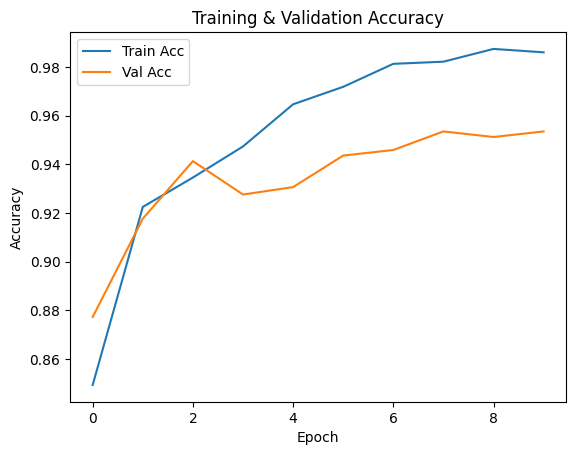

In [23]:
# 1. Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Set parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 10

# 3. Set dataset paths (Update if needed)
train_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Training'
test_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Testing'

# 4. Create data generators
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important for evaluation
)

# 5. Get number of classes
num_classes = len(train_generator.class_indices)
print("Classes:", train_generator.class_indices)

# 6. Load base model (MobileNetV2)
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False  # Freeze base layers

# 7. Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# 8. Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# 9. Train the model
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

# 10. Evaluate model
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# 11. Metrics
print("\nAccuracy:", accuracy_score(y_true, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=list(test_generator.class_indices.keys())))

# 12. Plot training results
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [27]:
model.save('mobilenet_brain_tumor.h5')
print("Model saved as mobilenet_brain_tumor.h5")


Model saved as mobilenet_brain_tumor.h5


In [29]:
from tensorflow.keras.models import load_model

cnn_model = load_model('cnn_model.h5')
mobilenet_model = load_model('mobilenet_brain_tumor.h5')


In [30]:
# True labels from test generator
y_true = test_generator.classes

# CNN predictions
y_pred_cnn_probs = cnn_model.predict(test_generator)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

# MobileNetV2 predictions
y_pred_mobilenet_probs = mobilenet_model.predict(test_generator)
y_pred_mobilenet = np.argmax(y_pred_mobilenet_probs, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())


41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 242ms/step


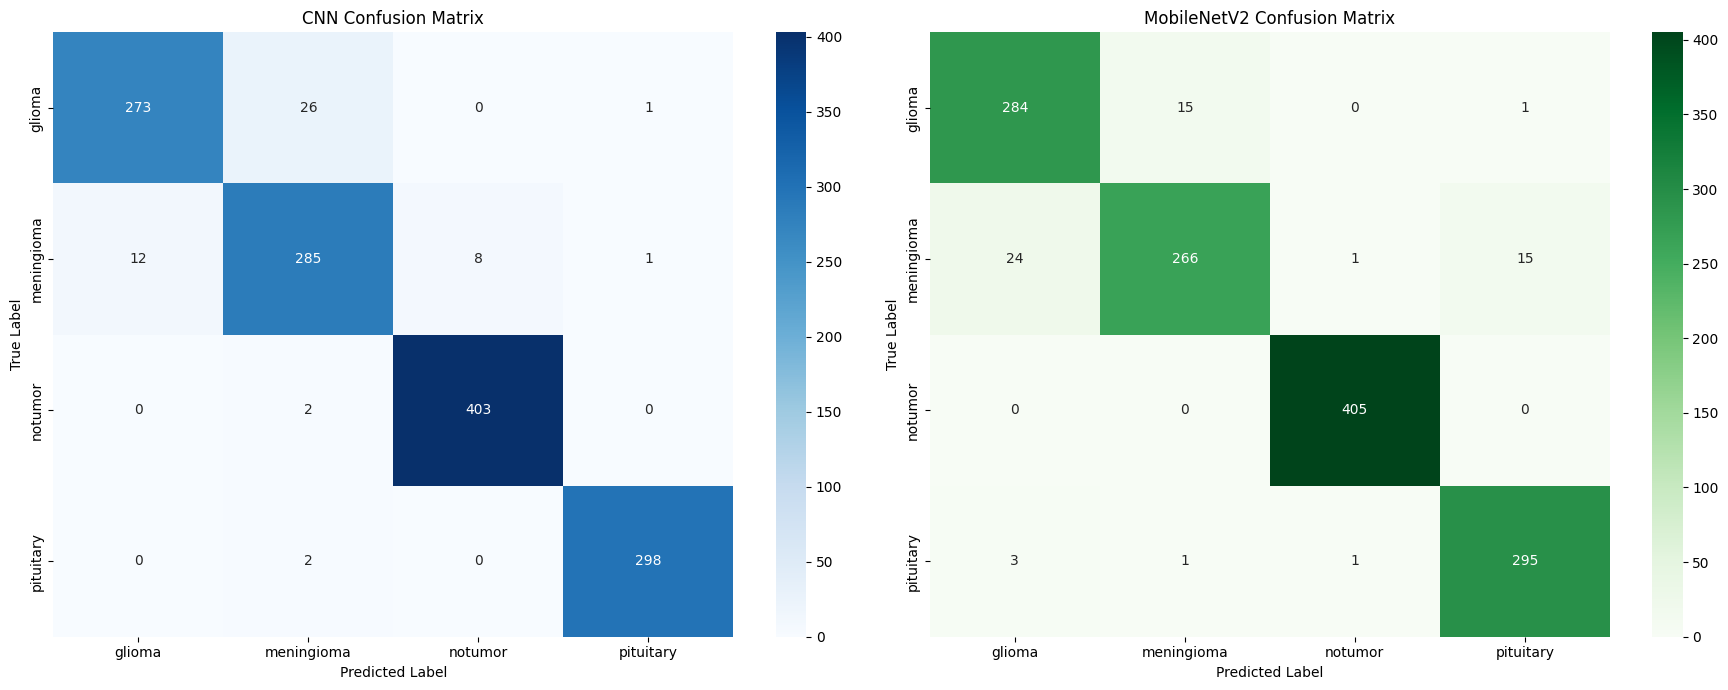

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Example: y_true, y_pred_cnn, y_pred_mobilenet, class_names
# y_true = test_generator.classes
# y_pred_cnn = np.argmax(cnn_model.predict(test_generator), axis=1)
# y_pred_mobilenet = np.argmax(mobilenet_model.predict(test_generator), axis=1)
# class_names = list(test_generator.class_indices.keys())

# Compute confusion matrices
cm_cnn = confusion_matrix(y_true, y_pred_cnn)
cm_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('CNN Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('MobileNetV2 Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [32]:
accuracy_dict = {
    "SVM": 0.9443,
    "Logistic Regression": 0.9428,
    "Decision Tree": 0.8330,
    "KNN": 0.8932,
    "XGBoost": 0.9413,
    "CNN": 0.96,
    "MobileNetV2": 0.9535
}


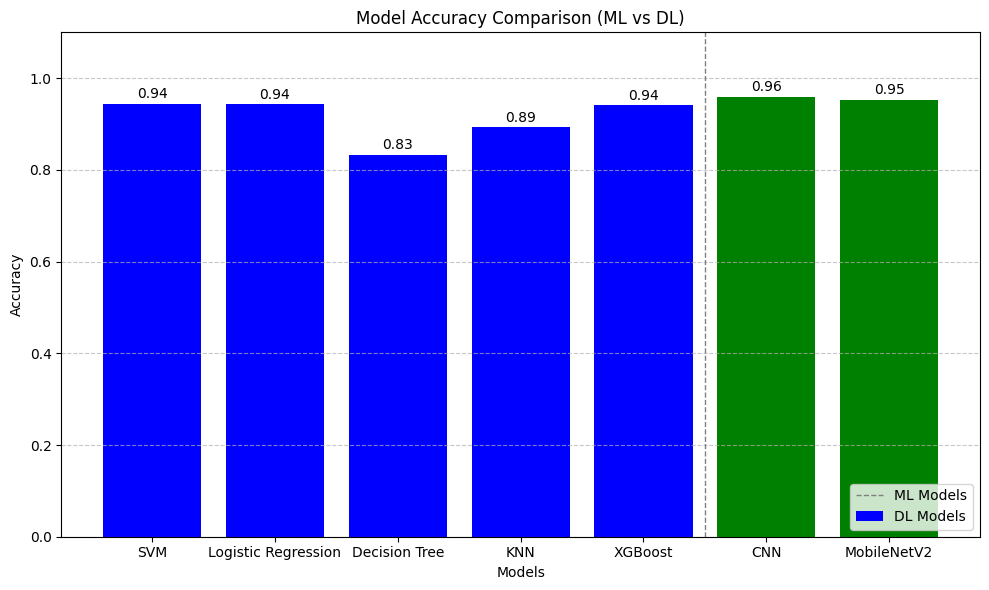

In [33]:
import matplotlib.pyplot as plt

# Extract model names and accuracies
models = list(accuracy_dict.keys())
accuracies = list(accuracy_dict.values())

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['blue']*5 + ['green']*2)

# Highlight ML and DL
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.005, f'{height:.2f}', ha='center', va='bottom')

plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison (ML vs DL)")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.axvline(4.5, color='gray', linestyle='--', linewidth=1)
plt.legend(["ML Models", "DL Models"], loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
